# Modelo Analítico: Flujo 2D Viscoso con Transferencia de Calor y Placa Móvil

## 1. Hipótesis
- Flujo **incompresible** ($\nabla \cdot \mathbf{u} = 0$) y **laminar**.
- Dominio **bidimensional** (variaciones en $x$ y $y$).
- Placa inferior ($y = 0$) se mueve con velocidad $-U_p \hat{i}$ (sentido $-x$).
- Gradiente de presión constante en $x$: $\frac{\partial p}{\partial x} = \text{const.}$
- Efectos gravitacionales despreciables.

## 2. Ecuaciones Gobernantes

### Conservación de Momento (Navier-Stokes 2D)
**Componente $x$**:
$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

**Componente $y$**:
$$
\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)
$$

donde:
- $u$, $v$: Componentes de velocidad en $x$ e $y$.
- $\nu = \mu/\rho$: Viscosidad cinemática.

### Conservación de Energía
$$
\frac{\partial T}{\partial t} + u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) + \frac{\Phi}{\rho c_p}
$$

**Disipación viscosa ($\Phi$)**:
$$
\Phi = \mu \left[ 2 \left( \frac{\partial u}{\partial x} \right)^2 + 2 \left( \frac{\partial v}{\partial y} \right)^2 + \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)^2 \right]
$$

### Esfuerzo Cortante ($\tau_{xy}$)
$$
\tau_{xy} = \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
$$

## 3. Condiciones de Frontera

<center>

| **Variable**   | **Placa Inferior ($y=0$)**       | **Superior ($y=H$)**       |
|----------------|----------------------------------|----------------------------|
| Velocidad $u$  | $u = -U_p$                       | $u = U_0$                  |
| Velocidad $v$  | $v = 0$ (no penetración)         | $v = 0$                    |
| Temperatura $T$| $T = T_0$                        | $T = T_1$                  |

</center>

## 4. Simplificaciones para Estado Estacionario
Si $\frac{\partial}{\partial t} = 0$ y $\frac{\partial p}{\partial x} = -\Delta p/L$:
$$
\nu \frac{d^2 u}{dy^2} = \frac{1}{\rho} \frac{\Delta p}{L}, \quad \text{con} \quad u(0) = -U_p, \quad u(H) = U_0
$$

**Solución analítica** para $u(y)$:
$$
u(y) = \frac{\Delta p}{2 \mu L} y (y - H) + \left(U_0 + U_p \frac{y}{H}\right) - U_p

Valor máximo de presión: 0.0000 en coordenadas (x, y) = (0.00, 0.00)
Valor máximo de temperatura: 18.7571 en coordenadas (x, y) = (1.96, 0.06)


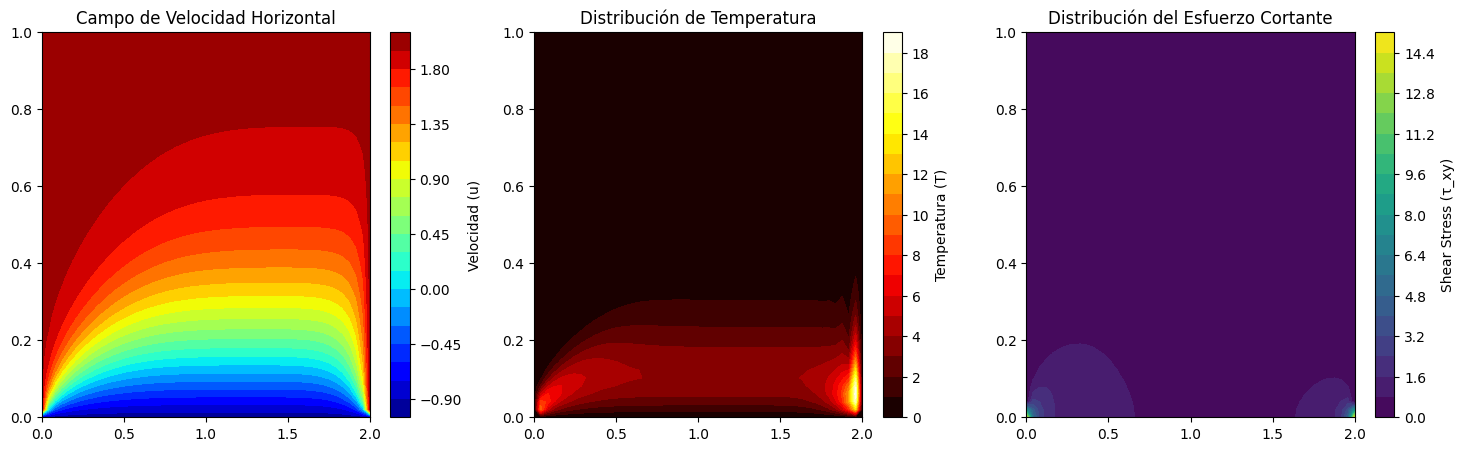

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# PARAMETROS DEL PROBLEMA
# Geometría
Lx, Ly = 2.0, 1.0  # Dimensiones del dominio (x, y)
nx, ny = 50, 50      # Número de puntos en la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# Propiedades del fluido
rho = 1.0            # Densidad
mu = 0.1             # Viscosidad dinámica
nu = mu / rho        # Viscosidad cinemática
alpha = 0.01         # Difusividad térmica
cp = 1.0             # Calor específico

# Condiciones de frontera
U_p = -1.0           # Velocidad de la placa (sentido contrario)
U_0 = 2.0            # Velocidad del flujo libre
T0, T1 = 0.0, 0.0    # Temperaturas de la placa y del fluido

# Tiempo
dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

## INICIALIZACIÓN

# Mallas
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Campos iniciales
u = np.zeros((ny, nx)) + U_0  # Velocidad horizontal
v = np.zeros((ny, nx))         # Velocidad vertical
T = np.zeros((ny, nx)) + T1    # Temperatura
p = np.zeros((ny, nx))         # Presión

# Aplicar condiciones de frontera
u[0, :] = U_p     # Placa inferior móvil
u[-1, :] = U_0    # Flujo libre superior
T[0, :] = T0      # Temperatura de la placa
T[-1, :] = T1     # Temperatura del fluido lejos de la 

# ... (todo el código anterior se mantiene igual hasta la parte de EVOLUCIÓN TEMPORAL)

# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)
for n in range(nt):
    # Copiar campos anteriores
    u_old = u.copy()
    v_old = v.copy()
    T_old = T.copy()

    # Resolver Navier-Stokes (simplificado)
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de u (componente x)
            u[i, j] = (u_old[i, j] + dt * (
                -u_old[i, j] * (u_old[i, j+1] - u_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (u_old[i+1, j] - u_old[i-1, j]) / (2*dy)
                + nu * (
                    (u_old[i, j+1] - 2*u_old[i, j] + u_old[i, j-1]) / dx**2
                    + (u_old[i+1, j] - 2*u_old[i, j] + u_old[i-1, j]) / dy**2
                )
            ))

            # Ecuación de T (temperatura)
            T[i, j] = (T_old[i, j] + dt * (
                -u_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (T_old[i+1, j] - T_old[i-1, j]) / (2*dy)
                + alpha * (
                    (T_old[i, j+1] - 2*T_old[i, j] + T_old[i, j-1]) / dx**2
                    + (T_old[i+1, j] - 2*T_old[i, j] + T_old[i-1, j]) / dy**2
                )
                + (mu / (rho * cp)) * (  # Disipación viscosa (simplificada)
                    2 * ((u_old[i, j+1] - u_old[i, j-1]) / (2*dx))**2
                    + 2 * ((v_old[i+1, j] - v_old[i-1, j]) / (2*dy))**2
                    + ((u_old[i+1, j] - u_old[i-1, j]) / (2*dy) 
                      + (v_old[i, j+1] - v_old[i, j-1]) / (2*dx))**2
                )
            ))

    # Aplicar condiciones de frontera nuevamente
    u[0, :] = U_p
    u[-1, :] = U_0
    v[:, 0] = v[:, -1] = 0
    T[0, :] = T0
    T[-1, :] = T1

# Encontrar los valores máximos y sus coordenadas
p_max = np.max(p)
t_max = np.max(T)

# Encontrar las coordenadas donde ocurren los máximos
p_max_coords = np.unravel_index(np.argmax(p), p.shape)
t_max_coords = np.unravel_index(np.argmax(T), T.shape)

# Convertir índices de la matriz a coordenadas físicas
p_max_x = x[p_max_coords[1]]
p_max_y = y[p_max_coords[0]]
t_max_x = x[t_max_coords[1]]
t_max_y = y[t_max_coords[0]]

# Imprimir resultados
print(f"Valor máximo de presión: {p_max:.4f} en coordenadas (x, y) = ({p_max_x:.2f}, {p_max_y:.2f})")
print(f"Valor máximo de temperatura: {t_max:.4f} en coordenadas (x, y) = ({t_max_x:.2f}, {t_max_y:.2f})")


# REPRESENTACIÓN

# Gráfico de velocidad y temperatura
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.contourf(X, Y, u, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (u)')
plt.title('Campo de Velocidad Horizontal')

plt.subplot(1, 3, 2)
plt.contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T)')
plt.title('Distribución de Temperatura')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u, dy, axis=0)
dvdx = np.gradient(v, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico del esfuerzo cortante
plt.subplot(1, 3, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Shear Stress (τ_xy)')
plt.title('Distribución del Esfuerzo Cortante')
plt.show()

## Adimensionalización

# Solución estacionaria

1. Navier-Stokes:
$$
u_\eta\partial_\eta u_\eta + \Lambda u_\sigma \partial_\sigma u_\eta = - Eu \;\partial_\eta \xi + \varphi (\partial_\eta^2u_\eta + \Lambda^2\partial_\sigma^2u_\eta) 
$$
$$
u_\eta\partial_\eta u_\sigma + \Lambda u_\sigma \partial_\sigma u_\sigma = - Eu \;\partial_\sigma \xi + \varphi (\partial_\eta^2u_\sigma + \Lambda^2\partial_\sigma^2u_\sigma)
$$

2. Energía:
$$
u_\eta\partial_\eta \theta + \Lambda u_\sigma \partial_\sigma \theta = \beta (\partial_\eta^2 \theta + \Lambda \partial_\sigma^2 \theta) + \delta (2((\partial_\eta u_\eta)^2 + \Lambda^2 (\partial_\sigma u_\sigma)^2) + (\partial_\eta u_\sigma + \partial_\sigma u_\eta)^2)
$$

Donde:

<center>

| $\eta = \frac{x}{L}$         | $\sigma = \frac{y}{H}$                  |$\tau = \frac{t}{t_c}$      |
|----------------|----------------------------------|----------------------------|
| $u_\eta = \frac{v_x}{u_0}$  | $u_\sigma = \frac{v_y}{u_0} $     | $\Lambda = \frac{L}{H}$      |
| $\theta = \frac{T - T_0}{T_f - T_0}$       | $\xi = \frac{p - p_0}{p_f - p_0}$ | $Re = \frac{\rho \;u_0 \;L}{\mu}$ |
| $t_c = \frac{L}{u_0}$  |  $\varphi = \frac{\nu}{L\;u_0}$    | $\beta = \frac{\alpha \;L^3}{u_0\; H^2}$   |
| $Eu = \frac{p_f-p_0}{\rho\;u_0^2}$  | $\delta = \frac{\mu\;u_0}{\rho\;C_p\;L}$      |     |

</center>